In [1]:
# Install (usually already installed in Colab)
!pip install pandas matplotlib numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving sales_data.csv to sales_data.csv


In [3]:
df = pd.read_csv('sales_data.csv', parse_dates=['Date'])

# Create Month column
df['Month'] = df['Date'].dt.to_period('M').astype(str)

# Preview
df.head()

,OrderID,Date,Region,Category,Product,UnitsSold,UnitPrice,Discount,CustomerAge,CustomerGender,TotalRevenue,Month
0,1001,2023-04-13,South,Clothing,Product_10,80,386.12,0.09,51,Male,28109.54,2023-04
1,1002,2024-03-11,East,Food,Product_30,27,280.54,0.24,59,Male,5756.68,2024-03
2,1003,2023-12-15,East,Sports,Product_46,72,131.54,0.03,33,Female,9186.75,2023-12
3,1004,2023-09-28,South,Sports,Product_23,60,154.52,0.11,55,Male,8251.37,2023-09
4,1005,2023-04-17,South,Electronics,Product_32,46,367.32,0.29,19,Female,11996.67,2023-04


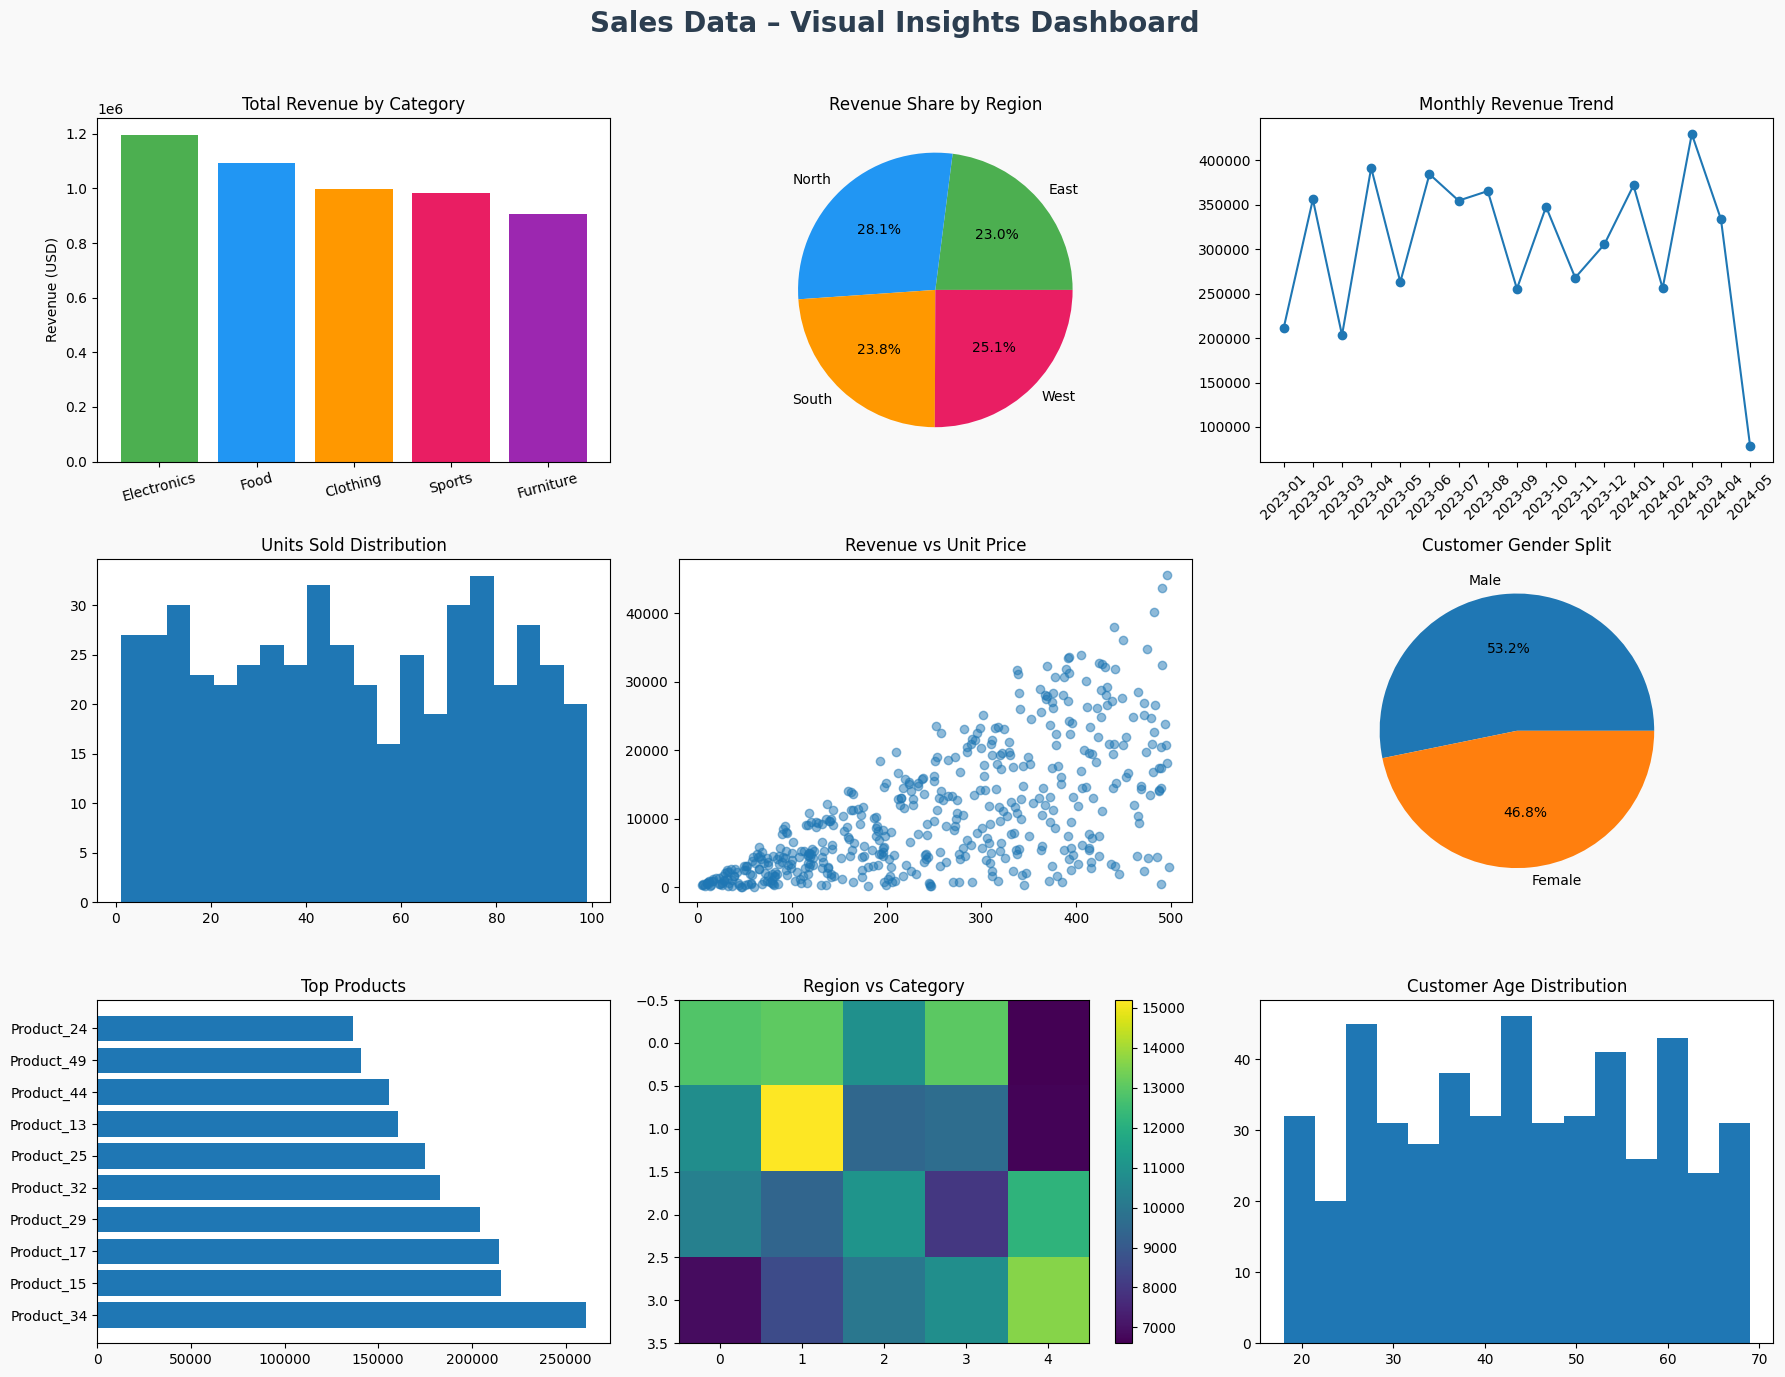

In [4]:
# Colors
COLORS  = ['#4CAF50', '#2196F3', '#FF9800', '#E91E63', '#9C27B0']
BG      = '#F9F9F9'

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor(BG)
fig.suptitle('Sales Data – Visual Insights Dashboard', fontsize=20,
             fontweight='bold', color='#2c3e50', y=0.98)

# ── 1. Revenue by Category ──
ax1 = fig.add_subplot(3, 3, 1)
rev_cat = df.groupby('Category')['TotalRevenue'].sum().sort_values(ascending=False)
bars = ax1.bar(rev_cat.index, rev_cat.values, color=COLORS)
ax1.set_title('Total Revenue by Category')
ax1.set_ylabel('Revenue (USD)')
ax1.tick_params(axis='x', rotation=15)

# ── 2. Revenue by Region ──
ax2 = fig.add_subplot(3, 3, 2)
rev_reg = df.groupby('Region')['TotalRevenue'].sum()
ax2.pie(rev_reg, labels=rev_reg.index, autopct='%1.1f%%', colors=COLORS)
ax2.set_title('Revenue Share by Region')

# ── 3. Monthly Trend ──
ax3 = fig.add_subplot(3, 3, 3)
monthly = df.groupby('Month')['TotalRevenue'].sum().reset_index()
monthly_sorted = monthly.sort_values('Month')
ax3.plot(monthly_sorted['Month'], monthly_sorted['TotalRevenue'], marker='o')
ax3.set_title('Monthly Revenue Trend')
ax3.tick_params(axis='x', rotation=45)

# ── 4. Units Sold ──
ax4 = fig.add_subplot(3, 3, 4)
ax4.hist(df['UnitsSold'], bins=20)
ax4.set_title('Units Sold Distribution')

# ── 5. Revenue vs Price ──
ax5 = fig.add_subplot(3, 3, 5)
ax5.scatter(df['UnitPrice'], df['TotalRevenue'], alpha=0.5)
ax5.set_title('Revenue vs Unit Price')

# ── 6. Gender Split ──
ax6 = fig.add_subplot(3, 3, 6)
gender = df['CustomerGender'].value_counts()
ax6.pie(gender, labels=gender.index, autopct='%1.1f%%')
ax6.set_title('Customer Gender Split')

# ── 7. Top Products ──
ax7 = fig.add_subplot(3, 3, 7)
top_products = df.groupby('Product')['TotalRevenue'].sum().nlargest(10)
ax7.barh(top_products.index, top_products.values)
ax7.set_title('Top Products')

# ── 8. Heatmap ──
ax8 = fig.add_subplot(3, 3, 8)
pivot = df.pivot_table(values='TotalRevenue', index='Region',
                       columns='Category', aggfunc='mean')
im = ax8.imshow(pivot, aspect='auto')
ax8.set_title('Region vs Category')
plt.colorbar(im, ax=ax8)

# ── 9. Age Distribution ──
ax9 = fig.add_subplot(3, 3, 9)
ax9.hist(df['CustomerAge'], bins=15)
ax9.set_title('Customer Age Distribution')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [5]:
fig.savefig('task4_visualizations.png', dpi=150)

In [6]:
from google.colab import files
files.download('task4_visualizations.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>